## Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from torch import from_numpy, Tensor
from torchmetrics import MetricCollection
import torchmetrics
import torchmetrics.text
import evaluate

import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
from tqdm import tqdm

tqdm.pandas()

In [3]:
meteor = evaluate.load("meteor")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
df_orig = pd.read_hdf(Path("eval-all") / "data" / "all_joined_judged.h5")
df_orig = df_orig[
    df_orig["sample_id"] >= 27000
].copy()  # Only do this for samples from the test split
df_orig

,setting,model,mode,sample_id,question_id,prediction_text,action_sequence,textual_description,question_type,question,answer_type,answer_text,answer,options,options_sequence,prediction_parsed_binary,prediction_parsed_multi,llm_judge_raw,llm_judge_rationale,llm_judge_score
30000,4.2.1,Falcon (7B),200,27000,0,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,right_after_open,"After engaging in bowing, what followed immedi...",open,Someone is waving.,NaN,NaN,NaN,NaN,NaN,"{\n\n ""BriefRationale"": ""The system_answer ...",The system_answer correctly identifies 'waving...,3
30001,4.2.1,Falcon (7B),200,27000,1,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,descriptive_identification_open,"At 2.803, what action is the person performing?",open,The person is bowing.,NaN,NaN,NaN,NaN,NaN,"{\n\n ""BriefRationale"": ""The system_answer ...",The system_answer incorrectly identifies the a...,1
30002,4.2.1,Falcon (7B),200,27000,2,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,descriptive_identification_multi,"What is the person doing at 4.354? A: waving, ...",multi,The correct answer is: waving.,0.0,"{'A': 'waving', 'B': 'bowing', 'C': 'picking s...","[waving, bowing, picking something up with bot...",NaN,A,<NA>,<NA>,<NA>
30003,4.2.1,Falcon (7B),200,27000,3,correct,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,count_binary,Is it accurate to state that the individual re...,binary,False,0.0,NaN,NaN,True,NaN,<NA>,<NA>,<NA>
30004,4.2.1,Falcon (7B),200,27000,4,"waving, picking something up with both hands, ...","{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,after_open,Following the performance of bowing by the per...,open,The subject is waving and picking something up...,NaN,NaN,NaN,NaN,NaN,"{""BriefRationale"": ""The system_answer correctl...",The system_answer correctly lists all actions ...,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1952099,4.4,NeSy xLSTM + Qwen3 (8B) GT,full,29999,0,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_least_binary,"In terms of occurrence, was the person's invol...",binary,True,1.0,NaN,NaN,False,NaN,NaN,NaN,NaN
1952100,4.4,NeSy xLSTM + Qwen3 (8B) GT,full,29999,1,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,comparison_first_last_same_binary,Are the initial and final actions identical to...,binary,No,0.0,NaN,NaN,False,NaN,NaN,NaN,NaN
1952101,4.4,NeSy xLSTM + Qwen3 (8B) GT,full,29999,2,A,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,before_multi,Some time before the person performed playing ...,multi,The correct answer is picking something up wit...,0.0,"{'A': 'picking something up with both hands', ...","[picking something up with both hands, jumping...",NaN,A,NaN,NaN,NaN
1952102,4.4,NeSy xLSTM + Qwen3 (8B) GT,full,29999,3,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_most_binary,Was kicking a ball the most frequently observe...,binary,This is not correct.,0.0,NaN,NaN,False,NaN,NaN,NaN,NaN


## Compute Metrics

### Binary Tasks

In [5]:
binary = df_orig[df_orig["answer_type"] == "binary"].copy()
binary.drop(
    columns=["options", "options_sequence", "prediction_parsed_multi"], inplace=True
)
binary["prediction_parsed_binary"].fillna(np.nan, inplace=True)
binary = binary.astype({"answer": int, "prediction_parsed_binary": float}, copy=False)

In [6]:
def unwrap(res: dict[str, Tensor]) -> dict[str, float]:
    return {k: v.item() for k, v in res.items()}


def compute_binary_metrics(df: pd.DataFrame) -> dict[str, float]:
    metrics = MetricCollection(
        {
            "Accuracy": torchmetrics.Accuracy(task="binary"),
            "Precision": torchmetrics.Precision(task="binary"),
            "Recall": torchmetrics.Recall(task="binary"),
            "F1": torchmetrics.F1Score(task="binary", average="macro"),
        }
    )

    return unwrap(
        metrics(
            from_numpy(df["prediction_parsed_binary"].to_numpy(na_value=-1)),
            from_numpy(df["answer"].to_numpy()),
        )
    )


all_results_binary = (
    binary.groupby(["setting", "model", "mode"])
    .apply(compute_binary_metrics)
    .apply(pd.Series)
    .reset_index()
)
all_results_binary

,setting,model,mode,Accuracy,F1,Precision,Recall
0,4.2.1,Falcon (7B),200,0.601799,0.629432,0.596998,0.665594
1,4.2.1,Falcon (7B),250,0.557972,0.384703,0.657076,0.271967
2,4.2.1,Falcon (7B),350,0.546361,0.359945,0.635697,0.251046
3,4.2.1,Falcon (7B),400,0.547179,0.379843,0.624448,0.272932
4,4.2.1,Falcon (7B),full,0.962551,0.963494,0.954517,0.972642
...,...,...,...,...,...,...,...
71,4.4,NeSy Qwen3 8B GT,full,0.804088,0.776659,0.922907,0.670422
72,4.4,NeSy xLSTM + Llama 3.1 (8B) AE,full,0.794603,0.782774,0.845981,0.728355
73,4.4,NeSy xLSTM + Llama 3.1 (8B) GT,full,0.794440,0.781657,0.849057,0.724171
74,4.4,NeSy xLSTM + Qwen3 (8B) AE,full,0.809975,0.784575,0.925230,0.681043


### Multi Tasks

In [7]:
multi = df_orig[df_orig["answer_type"] == "multi"].copy()
multi["prediction_parsed_multi"].fillna(np.nan, inplace=True)
multi.drop(columns=["prediction_parsed_binary"], inplace=True)

In [8]:
def compute_multi_metrics(df: pd.DataFrame) -> dict[str, float]:
    metrics = MetricCollection(
        {
            "Accuracy": torchmetrics.Accuracy(task="multiclass", num_classes=3),
            "Precision": torchmetrics.Precision(
                task="multiclass", average="macro", num_classes=3
            ),
            "Recall": torchmetrics.Recall(
                task="multiclass", average="macro", num_classes=3
            ),
            "F1": torchmetrics.F1Score(
                task="multiclass", num_classes=3, average="macro"
            ),
        }
    )

    ground_truth = df["answer"].to_numpy()

    predictions = (
        df["prediction_parsed_multi"]
        .map({"A": 0, "B": 1, "C": 2, "nan": pd.NA})
        .to_numpy(na_value=-1)
        .astype(np.int32)
    )
    # Make sure we put a wrong answer in case of NaN
    predictions[predictions == -1] = (ground_truth[predictions == -1] + 1) % 3

    return unwrap(
        metrics(
            from_numpy(predictions),
            from_numpy(ground_truth),
        )
    )


all_results_multi = (
    multi.groupby(["setting", "model", "mode"])
    .apply(compute_multi_metrics)
    .apply(pd.Series)
    .reset_index()
)
all_results_multi

,setting,model,mode,Accuracy,F1,Precision,Recall
0,4.2.1,Falcon (7B),200,0.596411,0.595906,0.597501,0.595959
1,4.2.1,Falcon (7B),250,0.676484,0.676226,0.680725,0.676661
2,4.2.1,Falcon (7B),350,0.606995,0.606749,0.607867,0.606691
3,4.2.1,Falcon (7B),400,0.469397,0.467880,0.471963,0.468917
4,4.2.1,Falcon (7B),full,0.995858,0.995852,0.995846,0.995859
...,...,...,...,...,...,...,...
71,4.4,NeSy Qwen3 8B GT,full,0.856190,0.856163,0.856454,0.856325
72,4.4,NeSy xLSTM + Llama 3.1 (8B) AE,full,0.811781,0.811794,0.813002,0.811857
73,4.4,NeSy xLSTM + Llama 3.1 (8B) GT,full,0.815002,0.814992,0.816356,0.815119
74,4.4,NeSy xLSTM + Qwen3 (8B) AE,full,0.879659,0.879652,0.879933,0.879835


### Open Tasks

In [9]:
open = df_orig[df_orig["answer_type"] == "open"].copy()
open.drop(
    columns=[
        "prediction_parsed_binary",
        "options",
        "answer",
        "options_sequence",
        "prediction_parsed_multi",
    ],
    inplace=True,
)

In [10]:
def compute_open_metrics(df: pd.DataFrame) -> dict[str, float]:
    inputs = (
        df["prediction_text"].fillna(""),
        df["answer_text"],
    )

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", category=FutureWarning, module="torch.nn.modules.module"
        )

        return {
            "BLEU": torchmetrics.text.BLEUScore()(*inputs).item(),
            "ROUGE": torchmetrics.text.ROUGEScore(
                use_stemmer=True, rouge_keys=("rouge1",)
            )(*inputs)["rouge1_fmeasure"].item(),
            "METEOR": meteor.compute(
                predictions=inputs[0].tolist(),
                references=inputs[1].tolist(),
            )["meteor"],
            "BERTScore": (
                torchmetrics.text.BERTScore(
                    model_name_or_path="roberta-large",
                    lang="en",
                    device="cuda",
                    batch_size=512,
                )(*inputs)["f1"]
                .mean()
                .item()
            ),
            # Also rescale the LLMJudge score to be between 0 and 1
            "LLMJudge": (df["llm_judge_score"].fillna(1).mean() - 1) / 2,
        }


all_results_open = (
    open.groupby(["setting", "model", "mode"])
    .progress_apply(compute_open_metrics)
    .apply(pd.Series)
    .reset_index()
)
all_results_open

100%|██████████| 76/76 [25:03<00:00, 19.79s/it]


,setting,model,mode,BLEU,ROUGE,METEOR,BERTScore,LLMJudge
0,4.2.1,Falcon (7B),200,0.0,0.198666,0.282416,0.972116,0.510024
1,4.2.1,Falcon (7B),250,0.0,0.214915,0.331673,0.972199,0.579092
2,4.2.1,Falcon (7B),350,0.0,0.203923,0.329550,0.971975,0.558713
3,4.2.1,Falcon (7B),400,0.0,0.203032,0.272586,0.972387,0.523573
4,4.2.1,Falcon (7B),full,0.0,0.335013,0.505252,0.972474,0.940185
...,...,...,...,...,...,...,...,...
71,4.4,NeSy Qwen3 8B GT,full,0.0,0.148094,0.363821,0.973742,0.799405
72,4.4,NeSy xLSTM + Llama 3.1 (8B) AE,full,0.0,0.089757,0.367895,0.975006,0.775281
73,4.4,NeSy xLSTM + Llama 3.1 (8B) GT,full,0.0,0.091258,0.367692,0.974648,0.772857
74,4.4,NeSy xLSTM + Qwen3 (8B) AE,full,0.0,0.178179,0.369244,0.943468,0.817581


## Save / Load metrics

In [11]:
all_results_binary.to_csv(
    Path("eval-all") / "data" / "all_results_binary.csv", index=False
)
all_results_multi.to_csv(
    Path("eval-all") / "data" / "all_results_multi.csv", index=False
)
all_results_open.to_csv(Path("eval-all") / "data" / "all_results_open.csv", index=False)

In [12]:
all_results_binary = pd.read_csv(Path("eval-all") / "data" / "all_results_binary.csv")
all_results_multi = pd.read_csv(Path("eval-all") / "data" / "all_results_multi.csv")
all_results_open = pd.read_csv(Path("eval-all") / "data" / "all_results_open.csv")

## Prepare results for paper

In [13]:
relevant_models = [
    # "Mistral (7B)",
    # "Gemma (2B)",
    "Gemma 7B",
    "Llama 3.1 8B",
    # "Llama 3 (8B)",
    # "Llama 2 (8B)",
    # "Falcon 2 (11B)",
    # "Falcon (7B)",
    "T5 Base",
    # "T5 Small",
    "ChatTS",
]

### Some basic statistics

Mainly about where data was not able to be parsed across variants.

In [14]:
df_orig

,setting,model,mode,sample_id,question_id,prediction_text,action_sequence,textual_description,question_type,question,answer_type,answer_text,answer,options,options_sequence,prediction_parsed_binary,prediction_parsed_multi,llm_judge_raw,llm_judge_rationale,llm_judge_score
30000,4.2.1,Falcon (7B),200,27000,0,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,right_after_open,"After engaging in bowing, what followed immedi...",open,Someone is waving.,NaN,NaN,NaN,NaN,NaN,"{\n\n ""BriefRationale"": ""The system_answer ...",The system_answer correctly identifies 'waving...,3
30001,4.2.1,Falcon (7B),200,27000,1,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,descriptive_identification_open,"At 2.803, what action is the person performing?",open,The person is bowing.,NaN,NaN,NaN,NaN,NaN,"{\n\n ""BriefRationale"": ""The system_answer ...",The system_answer incorrectly identifies the a...,1
30002,4.2.1,Falcon (7B),200,27000,2,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,descriptive_identification_multi,"What is the person doing at 4.354? A: waving, ...",multi,The correct answer is: waving.,0.0,"{'A': 'waving', 'B': 'bowing', 'C': 'picking s...","[waving, bowing, picking something up with bot...",NaN,A,<NA>,<NA>,<NA>
30003,4.2.1,Falcon (7B),200,27000,3,correct,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,count_binary,Is it accurate to state that the individual re...,binary,False,0.0,NaN,NaN,True,NaN,<NA>,<NA>,<NA>
30004,4.2.1,Falcon (7B),200,27000,4,"waving, picking something up with both hands, ...","{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,after_open,Following the performance of bowing by the per...,open,The subject is waving and picking something up...,NaN,NaN,NaN,NaN,NaN,"{""BriefRationale"": ""The system_answer correctl...",The system_answer correctly lists all actions ...,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1952099,4.4,NeSy xLSTM + Qwen3 (8B) GT,full,29999,0,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_least_binary,"In terms of occurrence, was the person's invol...",binary,True,1.0,NaN,NaN,False,NaN,NaN,NaN,NaN
1952100,4.4,NeSy xLSTM + Qwen3 (8B) GT,full,29999,1,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,comparison_first_last_same_binary,Are the initial and final actions identical to...,binary,No,0.0,NaN,NaN,False,NaN,NaN,NaN,NaN
1952101,4.4,NeSy xLSTM + Qwen3 (8B) GT,full,29999,2,A,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,before_multi,Some time before the person performed playing ...,multi,The correct answer is picking something up wit...,0.0,"{'A': 'picking something up with both hands', ...","[picking something up with both hands, jumping...",NaN,A,NaN,NaN,NaN
1952102,4.4,NeSy xLSTM + Qwen3 (8B) GT,full,29999,3,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_most_binary,Was kicking a ball the most frequently observe...,binary,This is not correct.,0.0,NaN,NaN,False,NaN,NaN,NaN,NaN


In [15]:
for_stat = df_orig[df_orig["model"] == "Llama 3.1 (8B)"]
for_stat = for_stat[for_stat["answer_type"].isin(["binary", "multi"])].copy()
for_stat["parsed"] = (
    for_stat["prediction_parsed_multi"].astype(str).replace("nan", pd.NA)
)
for_stat["parsed"].fillna(for_stat["prediction_parsed_binary"], inplace=True)
for_stat.loc[for_stat["parsed"] == "<NA>", "parsed"] = pd.NA
for_stat["parsed"].fillna(pd.NA, inplace=True)  # NaN -> pd.NA
is_open = for_stat["answer_type"] == "open"
for_stat.loc[is_open, "parsed"].fillna(
    for_stat.loc[is_open, "prediction_text"], inplace=True
)

for name, group in for_stat.groupby(["setting", "mode"]):
    print(f"\n{name}")
    print(group["parsed"].value_counts(dropna=False, normalize=True))


('4.2.1', '100')
parsed
False    0.321671
True     0.261830
A        0.151420
B        0.142338
C        0.117866
<NA>     0.004875
Name: proportion, dtype: float64

('4.2.1', '150')
parsed
False    0.403785
True     0.168531
A        0.150081
B        0.138897
C        0.124271
<NA>     0.014435
Name: proportion, dtype: float64

('4.2.1', '200')
parsed
False    0.309626
True     0.274830
B        0.141382
C        0.137081
A        0.134882
<NA>     0.002199
Name: proportion, dtype: float64

('4.2.1', '300')
parsed
False    0.385623
True     0.197782
B        0.140140
A        0.138037
C        0.134978
<NA>     0.003441
Name: proportion, dtype: float64

('4.2.1', '400')
parsed
False    0.340407
True     0.242711
C        0.137559
B        0.137272
A        0.136603
<NA>     0.005449
Name: proportion, dtype: float64

('4.2.1', '50')
parsed
False    0.332664
True     0.251219
A        0.153905
B        0.136698
C        0.107447
<NA>     0.018067
Name: proportion, dtype: float64

('4.

### For Section 4.2.1

/tmp/ipykernel_12067/3050738890.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{y.get_text()}%" for y in plt.gca().get_yticklabels()])


<Figure size 800x600 with 0 Axes>

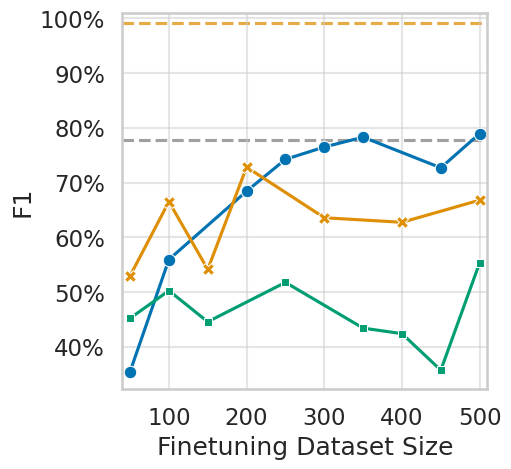

In [16]:
setting = "4.2.1"

show_legend = False

variant = "binary"
df = all_results_binary.copy()
human_baseline = 77.89
# variant = "multi"
# df = all_results_multi.copy()
# human_baseline = 86.54
metrics = ["Accuracy", "Precision", "Recall", "F1"]
metric = metrics[3]
ymin, ymax = None, 101
in_percent = True

# variant = "open"
# df = all_results_open.copy()
# human_baseline = 2.2313
# metrics = ["BLEU", "ROUGE", "METEOR", "BERTScore", "LLMJudge"]
# metric = metrics[4]
# ymin, ymax = 1.6, 3.0
# in_percent = False

df["model"] = df["model"].replace(
    {
        "Gemma (7B)": "Gemma 7B",
        "Llama 3.1 (8B)": "Llama 3.1 8B",
    }
)
df = df[df["model"].isin(relevant_models)]
df = df[df["setting"] == setting].copy()
df["mode"] = df["mode"].astype(str)
modes_sorted = sorted(
    [m for m in df["mode"].unique() if m != "full"], key=lambda x: int(x)
) + ["full"]
# Exclude "full" for now
modes_sorted = modes_sorted[:-1]
df_only_full = df[df["mode"] == "full"].copy()
df = df[df["mode"].isin(modes_sorted)].copy()
df["mode"] = df["mode"].astype(int)
# df["mode"] = pd.Categorical(df["mode"], categories=modes_sorted, ordered=True)

sns.set_style("whitegrid")
sns.set_context("talk")

if in_percent:
    df[metric] *= 100
    df_only_full[metric] *= 100

plt.figure(figsize=(8, 6))
grid = sns.relplot(
    data=df.rename(columns={"model": "Model"}),
    x="mode",
    y=metric,
    hue="Model",
    style="Model",
    kind="line",
    markers=True,
    dashes=False,
    hue_order=relevant_models,
    legend="auto" if show_legend else False,
    palette="colorblind",
)

# Add the full + human baselines in the background
plt.axhline(
    y=human_baseline,
    color="gray",
    alpha=0.75,
    linestyle="--",
    label="Humans (Motion)",
    zorder=0,
)
score = df_only_full[df_only_full["model"] == "Llama 3.1 8B"][metric].item()
plt.axhline(
    y=score,
    # use the color from the palette
    color=sns.color_palette("colorblind")[1],
    alpha=0.75,
    linestyle="--",
    label="Llama 3.1 8B (full)",
    zorder=0,
)

# Add a new legend containing the additional lines
if show_legend:
    grid.legend.remove()
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xlabel("Finetuning Dataset Size")
# plt.xlim(0, len(modes_sorted) - 1)
plt.xlim(min(df["mode"]) - 10, max(df["mode"]) + 10)

plt.ylabel(metric)
plt.ylim(ymin, ymax)
if in_percent:
    # Add percentage signs to y-ticks
    plt.gca().set_yticklabels([f"{y.get_text()}%" for y in plt.gca().get_yticklabels()])

plt.grid(True, linestyle="-", alpha=0.5)

sns.despine(top=False, right=False)

plt.savefig(
    Path("eval-all") / "plots" / f"{variant}_{metric.lower()}.pdf",
    bbox_inches="tight",
    pad_inches=0,
)
plt.show()

### For Section 4.2.1 - 4.2.4

In [24]:
df = all_results_binary
df = df[df["model"].isin(["Llama 3.1 (8B)"])]
df = df[(df["setting"] != "4.2.1") | (df["mode"] == "full")]
df = df[df["setting"].isin(["4.2.1", "4.2.2", "4.2.3", "4.2.4"])].copy()
df = df.set_index(["setting", "model", "mode"]) * 100
print(df[["Accuracy", "Precision", "Recall", "F1"]])

                              Accuracy  Precision     Recall         F1
setting model          mode                                            
4.2.1   Llama 3.1 (8B) full  99.100572  98.753995  99.485034  99.118167
4.2.2   Llama 3.1 (8B) full  55.224860  57.533687  45.349211  50.719941
4.2.3   Llama 3.1 (8B) 50    48.487327  48.794168  28.001288  35.582823
4.2.4   Llama 3.1 (8B) 50    49.795586  50.581580  51.786292  51.176846


In [25]:
df = all_results_multi
df = df[df["model"].isin(["Llama 3.1 (8B)"])]
df = df[(df["setting"] != "4.2.1") | (df["mode"] == "full")]
df = df[df["setting"].isin(["4.2.1", "4.2.2", "4.2.3", "4.2.4"])].copy()
df = df.set_index(["setting", "model", "mode"]) * 100
print(df[["Accuracy", "Precision", "Recall", "F1"]])

                              Accuracy  Precision     Recall         F1
setting model          mode                                            
4.2.1   Llama 3.1 (8B) full  99.976993  99.976480  99.977124  99.976790
4.2.2   Llama 3.1 (8B) full  64.473081  64.760667  64.397681  64.383233
4.2.3   Llama 3.1 (8B) 50     9.687068   9.579919   9.668659   9.616224
4.2.4   Llama 3.1 (8B) 50     0.276116   0.277555   0.275778   0.276616


In [23]:
df = all_results_open
df = df[df["model"].isin(["Llama 3.1 (8B)"])]
df = df[(df["setting"] != "4.2.1") | (df["mode"] == "full")]
df = df[df["setting"].isin(["4.2.1", "4.2.2", "4.2.3", "4.2.4"])].copy()
df = df.set_index(["setting", "model", "mode"])
print(df[["ROUGE", "METEOR", "LLMJudge", "BLEU", "BERTScore"]])

                                ROUGE    METEOR  LLMJudge  BLEU  BERTScore
setting model          mode                                               
4.2.1   Llama 3.1 (8B) full  0.337951  0.509947  0.943380   0.0   0.972418
4.2.2   Llama 3.1 (8B) full  0.205281  0.243621  0.602115   0.0   0.969019
4.2.3   Llama 3.1 (8B) 50    0.060323  0.057573  0.046045   0.0   0.968770
4.2.4   Llama 3.1 (8B) 50    0.027397  0.015414  0.017295   0.0   0.968260


### For Section 4.3 / 4.4

In [20]:
print(
    (
        all_results_binary[
            all_results_binary["setting"].isin(["4.3", "4.4"])
        ].set_index(["setting", "model", "mode"])
        * 100
    )[["Accuracy", "Precision", "Recall", "F1"]].to_string()
)

                                                 Accuracy  Precision     Recall         F1
setting model                          mode                                               
4.3     Human                          organic  77.580070  81.219512  74.831462  77.894735
4.4     ChatTS                         full     51.692557  55.375963  25.362086  34.790286
        NeSy Llama 3.1 8B AE           full     76.941943  81.886506  70.131958  75.554782
        NeSy Llama 3.1 8B GT           full     76.974654  82.214636  69.777918  75.487465
        NeSy Qwen3 8B AE               full     80.490595  92.495561  67.042160  77.738386
        NeSy Qwen3 8B GT               full     80.408829  92.290652  67.042160  77.665919
        NeSy xLSTM + Llama 3.1 (8B) AE full     79.460341  84.598130  72.835535  78.277415
        NeSy xLSTM + Llama 3.1 (8B) GT full     79.443991  84.905660  72.417122  78.165710
        NeSy xLSTM + Qwen3 (8B) AE     full     80.997545  92.522955  68.104279  78.457546

In [21]:
print(
    (
        all_results_multi[all_results_multi["setting"].isin(["4.3", "4.4"])].set_index(
            ["setting", "model", "mode"]
        )
        * 100
    )[["Accuracy", "Precision", "Recall", "F1"]].to_string()
)

                                                 Accuracy  Precision     Recall         F1
setting model                          mode                                               
4.3     Human                          organic  86.585367  86.552972  86.608291  86.544788
4.4     ChatTS                         full     30.395767  30.127978  30.579427  29.124486
        NeSy Llama 3.1 8B AE           full     67.533362  68.441361  67.575097  67.151290
        NeSy Llama 3.1 8B GT           full     67.234236  68.291312  67.256814  66.824770
        NeSy Qwen3 8B AE               full     85.503912  85.511506  85.520852  85.500288
        NeSy Qwen3 8B GT               full     85.618961  85.645354  85.632503  85.616297
        NeSy xLSTM + Llama 3.1 (8B) AE full     81.178093  81.300151  81.185746  81.179368
        NeSy xLSTM + Llama 3.1 (8B) GT full     81.500232  81.635618  81.511915  81.499249
        NeSy xLSTM + Qwen3 (8B) AE     full     87.965947  87.993312  87.983537  87.965202

In [22]:
print(
    (
        all_results_open[all_results_open["setting"].isin(["4.3", "4.4"])].set_index(
            ["setting", "model", "mode"]
        )
    )[["ROUGE", "METEOR", "LLMJudge", "BLEU", "BERTScore"]].to_string()
)

                                                   ROUGE    METEOR  LLMJudge  BLEU  BERTScore
setting model                          mode                                                  
4.3     Human                          organic  0.095508  0.263357  0.615646   0.0   0.975578
4.4     ChatTS                         full     0.045509  0.105950  0.070170   0.0   0.972928
        NeSy Llama 3.1 8B AE           full     0.129803  0.364941  0.707975   0.0   0.972535
        NeSy Llama 3.1 8B GT           full     0.132120  0.367441  0.705882   0.0   0.972597
        NeSy Qwen3 8B AE               full     0.148417  0.362943  0.798854   0.0   0.973569
        NeSy Qwen3 8B GT               full     0.148094  0.363821  0.799405   0.0   0.973742
        NeSy xLSTM + Llama 3.1 (8B) AE full     0.089757  0.367895  0.775281   0.0   0.975006
        NeSy xLSTM + Llama 3.1 (8B) GT full     0.091258  0.367692  0.772857   0.0   0.974648
        NeSy xLSTM + Qwen3 (8B) AE     full     0.178179  0.

## Per-Question-Type Breakdown: Humans vs. xQA-Qwen (AE)

Tables 2 and 3 report Humans and the xQA systems as one aggregate number per answer format. This
section breaks both down over all 45 question types of QuAnTS, laid out like Figure 5.

Needs the cells above that build the `binary`, `multi`, and `open` frames, but *not* the expensive
`compute_open_metrics` cell -- no BERTScore and no GPU are required here.

In [ ]:
# Work no matter whether the notebook is executed from the repo root or from eval-all/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists())
DATA = ROOT / "eval-all" / "data"
PLOTS = ROOT / "eval-all" / "plots"
PLOTS.mkdir(exist_ok=True)

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.15)  # readable once the figure is scaled down in the paper
PALETTE = sns.color_palette("colorblind")
plt.rcParams["pdf.fonttype"] = 42  # TrueType instead of Type 3, required by most camera-ready checks
plt.rcParams["ps.fonttype"] = 42

RNG = np.random.default_rng(0)
N_BOOT = 2_000

# The stored model names predate the paper's renaming: "xQA-Qwen" is the xLSTM-based system, not
# the "NeSy Qwen3 8B" one. The reproduction check below pins this mapping to Tables 2 and 3.
SYSTEMS = {
    "Humans": ("4.3", "Human", "organic"),
    "xQA-Qwen on AE": ("4.4", "NeSy xLSTM + Qwen3 (8B) AE", "full"),
}

SPLITS = {"binary": binary, "multi": multi, "open": open}
METRIC_LABELS = {"binary": "F1", "multi": "Macro F1", "open": "LLM judge"}
ANSWER_COLORS = dict(zip(SPLITS, PALETTE))  # binary blue, multi orange, open green, as in Figure 5

In [ ]:
def f1_binary(predictions: np.ndarray, targets: np.ndarray) -> float:
    """Positive-class F1, matching `F1Score(task="binary")`."""
    positive = predictions == 1
    tp = np.count_nonzero(positive & (targets == 1))
    fp = np.count_nonzero(positive & (targets == 0))
    fn = np.count_nonzero(~positive & (targets == 1))
    denominator = 2 * tp + fp + fn
    return 2 * tp / denominator if denominator else 0.0


def f1_macro_multi(predictions: np.ndarray, targets: np.ndarray) -> float:
    """Macro-averaged F1 over the three answer options."""
    scores = []
    for c in range(3):
        predicted = predictions == c
        actual = targets == c
        tp = np.count_nonzero(predicted & actual)
        fp = np.count_nonzero(predicted & ~actual)
        fn = np.count_nonzero(~predicted & actual)
        denominator = 2 * tp + fp + fn
        scores.append(2 * tp / denominator if denominator else 0.0)
    return float(np.mean(scores))


def rows_of(split: pd.DataFrame, system: str) -> pd.DataFrame:
    setting, model, mode = SYSTEMS[system]
    return split[
        (split["setting"] == setting)
        & (split["model"] == model)
        & (split["mode"].astype(str) == mode)
    ]


# One frame per split holding only the two systems, plus the per-response arrays each metric needs.
# Keeping the metrics index-based is what makes 90 groups x 2000 resamples cheap.
COMPARED = {
    name: pd.concat([rows_of(split, s) for s in SYSTEMS]) for name, split in SPLITS.items()
}

binary_predictions = (
    COMPARED["binary"]["prediction_parsed_binary"].to_numpy(na_value=-1) == 1
).astype(np.int64)
binary_targets = COMPARED["binary"]["answer"].to_numpy().astype(np.int64)

multi_targets = COMPARED["multi"]["answer"].to_numpy().astype(np.int64)
multi_predictions = (
    COMPARED["multi"]["prediction_parsed_multi"]
    .map({"A": 0, "B": 1, "C": 2, "nan": pd.NA})
    .to_numpy(na_value=-1)
    .astype(np.int64)
)
# Make sure we put a wrong answer in case of NaN
multi_predictions[multi_predictions == -1] = (multi_targets[multi_predictions == -1] + 1) % 3

open_scores = COMPARED["open"]["llm_judge_score"].fillna(1).to_numpy(dtype=float)

METRICS = {
    "binary": lambda idx: f1_binary(binary_predictions[idx], binary_targets[idx]),
    "multi": lambda idx: f1_macro_multi(multi_predictions[idx], multi_targets[idx]),
    "open": lambda idx: (open_scores[idx].mean() - 1) / 2,
}

# Row positions within each COMPARED frame, per system
POSITIONS = {
    name: {
        system: np.flatnonzero(
            (frame["setting"] == SYSTEMS[system][0])
            & (frame["model"] == SYSTEMS[system][1])
            & (frame["mode"].astype(str) == SYSTEMS[system][2])
        )
        for system in SYSTEMS
    }
    for name, frame in COMPARED.items()
}

In [ ]:
# Pooled over all question types, both systems have to land on the published numbers again --
# this is what keeps the "NeSy xLSTM + Qwen3 (8B) AE" -> "xQA-Qwen on AE" mapping honest.
published = {
    name: pd.read_csv(DATA / f"all_results_{name}.csv").set_index(["setting", "model", "mode"])
    for name in SPLITS
}

for name in SPLITS:
    column = "LLMJudge" if name == "open" else "F1"
    for system, key in SYSTEMS.items():
        value = METRICS[name](POSITIONS[name][system])
        reference = published[name].loc[key, column]
        print(f"{name:>6} / {system:<15}: {value:.6f} (published {reference:.6f})")
        assert np.isclose(value, reference, atol=1e-6), (name, system)

In [ ]:
def score_with_ci(metric, idx: np.ndarray) -> tuple[float, float, float]:
    """The metric on this group of responses, with a percentile bootstrap interval."""
    resampled = np.array(
        [metric(RNG.choice(idx, size=idx.size, replace=True)) for _ in range(N_BOOT)]
    )
    low, high = np.percentile(resampled, [2.5, 97.5])
    return metric(idx), low, high


records = []
for name, frame in COMPARED.items():
    question_types = frame["question_type"].to_numpy()
    for system in SYSTEMS:
        available = POSITIONS[name][system]
        for question_type in sorted(np.unique(question_types)):
            idx = available[question_types[available] == question_type]
            assert idx.size, (name, system, question_type)
            score, low, high = score_with_ci(METRICS[name], idx)
            records.append(
                {
                    "system": system,
                    "answer_type": name,
                    "question_type": question_type,
                    "n": idx.size,
                    "score": score,
                    "ci_low": low,
                    "ci_high": high,
                }
            )

breakdown = pd.DataFrame(records)
assert breakdown["question_type"].nunique() == 45, breakdown["question_type"].nunique()
assert len(breakdown) == 45 * len(SYSTEMS), len(breakdown)
breakdown.to_csv(DATA / "question_type_breakdown.csv", index=False)
breakdown.head()

In [ ]:
# binary -> multi -> open, alphabetically within each block. That is Figure 5's order read
# bottom-up; this figure reads top-down instead.
BLOCKS = {
    name: sorted(breakdown.loc[breakdown["answer_type"] == name, "question_type"].unique())
    for name in SPLITS
}
QUESTION_TYPE_ORDER = [q for name in SPLITS for q in BLOCKS[name]]
assert len(QUESTION_TYPE_ORDER) == 45, len(QUESTION_TYPE_ORDER)
{name: len(types) for name, types in BLOCKS.items()}

In [ ]:
from matplotlib.transforms import blended_transform_factory

OFFSETS = {"Humans": -0.2, "xQA-Qwen on AE": 0.2}  # first system on top of each pair


def shade(colour, system: str):
    """Humans get a washed-out, hatched version of the answer type's colour, xQA-Qwen the solid one.

    Colour therefore stays free to encode the answer type, as in Figure 5, and the hatch keeps the
    two systems apart even when the figure is printed in grayscale.
    """
    if system == "Humans":
        return tuple(1 - 0.45 * (1 - c) for c in colour)
    return colour


# Row positions, with a gap between the answer-type blocks so the separators can breathe
GAP = 1.0
ROWS, SEPARATORS, cursor = {}, [], 0.0
for i, name in enumerate(SPLITS):
    if i:
        SEPARATORS.append(cursor + (GAP - 1) / 2)
        cursor += GAP
    for question_type in BLOCKS[name]:
        ROWS[question_type] = cursor
        cursor += 1

fig, ax = plt.subplots(figsize=(12, 20))
indexed = breakdown.set_index(["system", "question_type"])

for system in SYSTEMS:
    subset = indexed.loc[system].loc[QUESTION_TYPE_ORDER]
    values = subset["score"].to_numpy() * 100
    errors = np.abs(np.stack([subset["ci_low"], subset["ci_high"]]) * 100 - values)
    y = np.array([ROWS[q] for q in QUESTION_TYPE_ORDER]) + OFFSETS[system]
    colours = [ANSWER_COLORS[a] for a in subset["answer_type"]]

    ax.barh(
        y,
        values,
        height=0.38,
        color=[shade(c, system) for c in colours],
        edgecolor=colours,
        linewidth=0.8,
        hatch="//" if system == "Humans" else None,
        zorder=2,
    )
    ax.errorbar(
        values,
        y,
        xerr=errors,
        fmt="none",
        ecolor="0.25",
        elinewidth=1.2,
        capsize=3,
        zorder=3,
    )

# Separators between the binary / multi / open blocks
for separator in SEPARATORS:
    ax.axhline(separator, color="0.2", linewidth=1.0, zorder=1)

ax.set_yticks([ROWS[q] for q in QUESTION_TYPE_ORDER], QUESTION_TYPE_ORDER)
ax.set_ylim(cursor - 0.5, -0.5)
ax.set_ylabel("Question Type")
ax.set_xlim(0, 103)
ax.set_xticks(np.arange(0, 101, 20), [f"{x}%" for x in range(0, 101, 20)])
ax.set_xlabel("Score")  # the legend already spells out the metric per answer type
ax.grid(True, axis="x", linestyle="-", alpha=0.5)
ax.grid(False, axis="y")
sns.despine(ax=ax, top=False, right=False)

# Colour says which answer type, shading says which system -- one legend row each, stacked above
# the axes. They are centred over the figure rather than over the axes, so that the wide
# answer-type row spans the question-type labels too instead of overhanging to the right, and so
# that the two rows line up with each other. The vertical offsets are in axes fractions, and this
# axes is tall, so they are small.
legend_anchor = blended_transform_factory(fig.transFigure, ax.transAxes)

system_legend = ax.legend(
    handles=[
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=shade((0.35, 0.35, 0.35), system),
            edgecolor="0.35",
            hatch="//" if system == "Humans" else None,
            label=system,
        )
        for system in SYSTEMS
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.026),
    bbox_transform=legend_anchor,
    ncol=len(SYSTEMS),
    fontsize="small",
    frameon=False,
)
ax.add_artist(system_legend)
answer_legend = ax.legend(
    handles=[
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=ANSWER_COLORS[name],
            label=f"{name.capitalize()} ({METRIC_LABELS[name]})",
        )
        for name in SPLITS
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.002),
    bbox_transform=legend_anchor,
    ncol=len(SPLITS),
    fontsize="small",
    frameon=False,
)

fig.tight_layout()
# Both legends sit outside the axes, so they have to be named explicitly or the tight bounding box
# crops the upper one away
fig.savefig(
    PLOTS / "question_type_breakdown.pdf",
    bbox_inches="tight",
    pad_inches=0,
    bbox_extra_artists=[system_legend, answer_legend],
)
plt.show()

In [ ]:
# A technical caption for the figure, with every number read back off the computed frame so that
# it cannot drift from what was actually plotted.
totals = breakdown.groupby("system")["n"].sum()
spans = breakdown.groupby("system")["n"].agg(["min", "max"])

print(
    f"Per-question-type performance of Humans (n = {totals['Humans']:,} responses) and xQA-Qwen on "
    f"AE (n = {totals['xQA-Qwen on AE']:,} answers) on the QuAnTS test split, over all "
    f"{len(QUESTION_TYPE_ORDER)} question types, ordered binary -> multi -> open and "
    "alphabetically within each block. Bars show positive-class F1 (binary), macro-averaged F1 "
    "over the three options (multi), and the LLM-judge score rescaled from [1, 3] to [0, 1] "
    "(open); answers that cannot be parsed are counted as wrong, as everywhere else in the paper. "
    f"Error bars are 95% percentile bootstrap intervals from {N_BOOT:,} resamples of the responses "
    "within each question type (seed 0); they are not corrected for multiple comparisons across "
    f"the {len(QUESTION_TYPE_ORDER)} types. They are consistently wider for Humans because the "
    f"study contributes only {spans.loc['Humans', 'min']}-{spans.loc['Humans', 'max']} responses "
    f"per question type, against {spans.loc['xQA-Qwen on AE', 'min']}-"
    f"{spans.loc['xQA-Qwen on AE', 'max']} answers for xQA-Qwen on AE."
)